In [8]:
# ── Core Data Libraries ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── ML Preprocessing ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# ── ML Models ─────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# ── Model Evaluation ──────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score
)

# ── Serialization ─────────────────────────────────────────────────────────────
import joblib
import os

# ── Plot Style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('✅ All libraries imported successfully!')
print(f'   Pandas  : {pd.__version__}')
print(f'   NumPy   : {np.__version__}')
print(f'   Sklearn : {__import__("sklearn").__version__}')

✅ All libraries imported successfully!
   Pandas  : 2.2.3
   NumPy   : 2.1.3
   Sklearn : 1.6.1


In [9]:
# ── Load Dataset ──────────────────────────────────────────────────────────────
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'

try:
    df = pd.read_csv(URL, sep=';')
    print(f'✅ Dataset loaded from URL — {df.shape[0]} rows × {df.shape[1]} columns')
except Exception:
    # Fallback: generate synthetic data with same schema
    print('⚠️  URL unavailable — generating synthetic dataset...')
    np.random.seed(42)
    n = 1599
    df = pd.DataFrame({
        'fixed acidity':       np.round(np.random.normal(8.32, 1.74, n), 2),
        'volatile acidity':    np.round(np.random.normal(0.53, 0.18, n), 2),
        'citric acid':         np.round(np.random.normal(0.27, 0.19, n), 2),
        'residual sugar':      np.round(np.random.normal(2.54, 1.41, n), 2),
        'chlorides':           np.round(np.random.normal(0.087, 0.047, n), 3),
        'free sulfur dioxide': np.round(np.random.normal(15.87, 10.46, n), 1),
        'total sulfur dioxide':np.round(np.random.normal(46.47, 32.9, n), 1),
        'density':             np.round(np.random.normal(0.9967, 0.0019, n), 4),
        'pH':                  np.round(np.random.normal(3.31, 0.154, n), 2),
        'sulphates':           np.round(np.random.normal(0.658, 0.17, n), 2),
        'alcohol':             np.round(np.random.normal(10.42, 1.07, n), 1),
        'quality':             np.random.choice([3,4,5,6,7,8], n, p=[0.006,0.033,0.426,0.399,0.124,0.012])
    })
    print(f'✅ Synthetic dataset ready — {df.shape[0]} rows × {df.shape[1]} columns')

df.head(10)

✅ Dataset loaded from URL — 1599 rows × 12 columns


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [10]:
# ── Basic Info ────────────────────────────────────────────────────────────────
print('── Dataset Shape ──')
print(f'  Rows: {df.shape[0]}, Columns: {df.shape[1]}')

print('\n── Column Data Types ──')
print(df.dtypes)

print('\n── Quality Score Distribution ──')
print(df['quality'].value_counts().sort_index())

── Dataset Shape ──
  Rows: 1599, Columns: 12

── Column Data Types ──
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

── Quality Score Distribution ──
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [11]:
# ── Statistical Summary ───────────────────────────────────────────────────────
df.describe().T.style.background_gradient(cmap='YlOrRd', subset=['mean','std'])

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.000000,8.319637,1.741096,4.600000,7.100000,7.900000,9.200000,15.900000
volatile acidity,1599.000000,0.527821,0.179060,0.120000,0.390000,0.520000,0.640000,1.580000
citric acid,1599.000000,0.270976,0.194801,0.000000,0.090000,0.260000,0.420000,1.000000
residual sugar,1599.000000,2.538806,1.409928,0.900000,1.900000,2.200000,2.600000,15.500000
chlorides,1599.000000,0.087467,0.047065,0.012000,0.070000,0.079000,0.090000,0.611000
free sulfur dioxide,1599.000000,15.874922,10.460157,1.000000,7.000000,14.000000,21.000000,72.000000
total sulfur dioxide,1599.000000,46.467792,32.895324,6.000000,22.000000,38.000000,62.000000,289.000000
density,1599.000000,0.996747,0.001887,0.990070,0.995600,0.996750,0.997835,1.003690
pH,1599.000000,3.311113,0.154386,2.740000,3.210000,3.310000,3.400000,4.010000
sulphates,1599.000000,0.658149,0.169507,0.330000,0.550000,0.620000,0.730000,2.000000


In [12]:
# ── 3.1 Check Missing Values ──────────────────────────────────────────────────
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else '  ✅ No missing values found!')

# ── 3.2 Check Duplicate Rows ──────────────────────────────────────────────────
dupes = df.duplicated().sum()
print(f'\nDuplicate rows: {dupes}')
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f'  ✅ Removed {dupes} duplicates → {df.shape[0]} rows remaining')
else:
    print('  ✅ No duplicates found!')

Missing values per column:
  ✅ No missing values found!

Duplicate rows: 240
  ✅ Removed 240 duplicates → 1359 rows remaining


In [13]:
# ── 3.3 Outlier Detection using IQR ───────────────────────────────────────────
features = df.columns.drop('quality')

outlier_summary = []
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({'Feature': col, 'Outliers': n_out, 'Lower Bound': round(lower,3), 'Upper Bound': round(upper,3)})

outlier_df = pd.DataFrame(outlier_summary)
print('Outlier Summary (IQR Method):')
print(outlier_df.to_string(index=False))

Outlier Summary (IQR Method):
             Feature  Outliers  Lower Bound  Upper Bound
       fixed acidity        41        3.950       12.350
    volatile acidity        19        0.015        1.015
         citric acid         1       -0.420        0.940
      residual sugar       126        0.850        3.650
           chlorides        87        0.039        0.122
 free sulfur dioxide        26      -14.000       42.000
total sulfur dioxide        45      -39.500      124.500
             density        35        0.992        1.001
                  pH        28        2.925        3.685
           sulphates        55        0.280        1.000
             alcohol        12        7.100       13.500


In [14]:
# ── 3.4 Cap Outliers with Winsorization (clip to 1st/99th percentile) ─────────
df_clean = df.copy()
for col in features:
    lo, hi = df_clean[col].quantile(0.01), df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(lo, hi)

print(f'✅ Outliers capped (Winsorization) — shape: {df_clean.shape}')

✅ Outliers capped (Winsorization) — shape: (1359, 12)


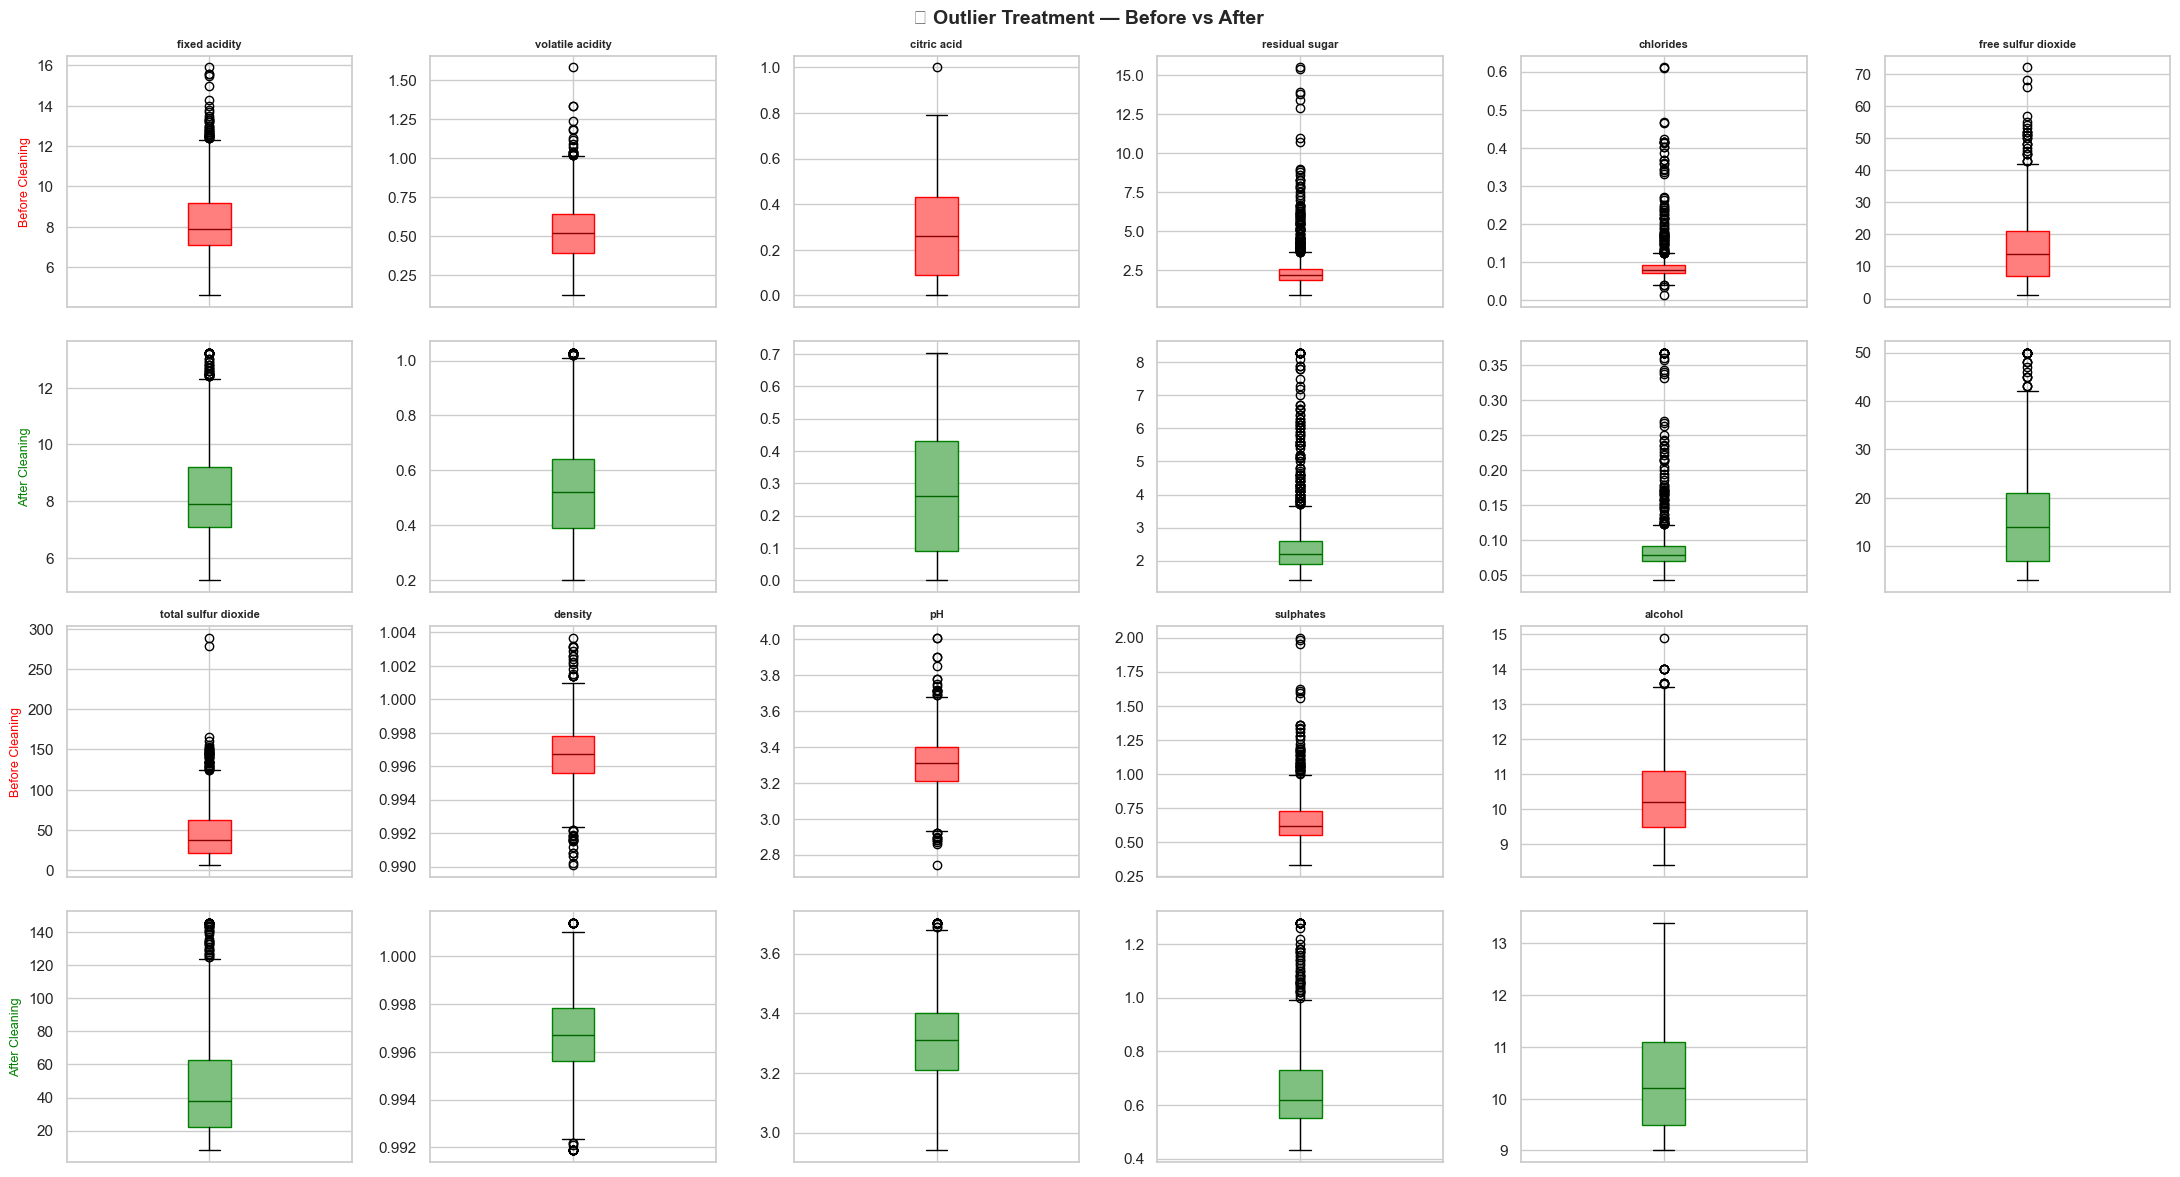

In [18]:
# ── 3.5 Visualize Boxplots Before vs After Cleaning ───────────────────────────
n_cols = 6
fig, axes = plt.subplots(4, n_cols, figsize=(22, 12))

for i, col in enumerate(features):
    row_before = (i // n_cols) * 2
    row_after  = row_before + 1
    col_idx    = i % n_cols

    axes[row_before, col_idx].boxplot(df[col], patch_artist=True,
                                       boxprops=dict(facecolor='#FF7F7F', color='red'),
                                       medianprops=dict(color='darkred'))
    axes[row_before, col_idx].set_title(col, fontsize=8, fontweight='bold')
    axes[row_before, col_idx].set_xticklabels([])

    axes[row_after, col_idx].boxplot(df_clean[col], patch_artist=True,
                                      boxprops=dict(facecolor='#7FBF7F', color='green'),
                                      medianprops=dict(color='darkgreen'))
    axes[row_after, col_idx].set_xticklabels([])

# Hide the 2 unused cells (11 features in a 6-col grid → last slot empty)
axes[2, 5].set_visible(False)
axes[3, 5].set_visible(False)

axes[0, 0].set_ylabel('Before Cleaning', fontsize=9, color='red')
axes[1, 0].set_ylabel('After Cleaning',  fontsize=9, color='green')
axes[2, 0].set_ylabel('Before Cleaning', fontsize=9, color='red')
axes[3, 0].set_ylabel('After Cleaning',  fontsize=9, color='green')

plt.suptitle('🧹 Outlier Treatment — Before vs After', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', bbox_inches='tight')
plt.show()

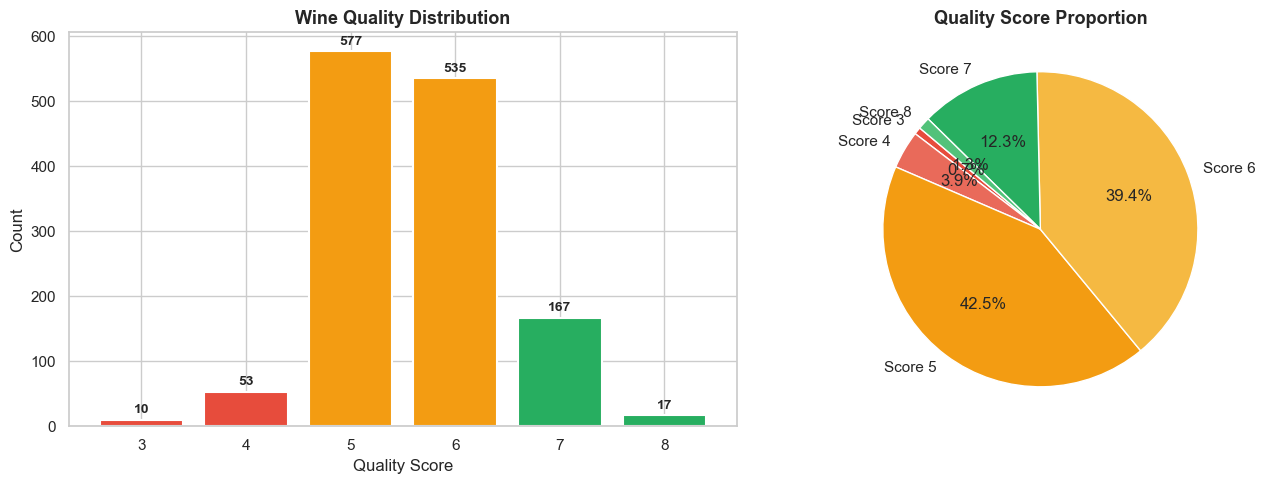

In [19]:
# ── 4.1 Quality Distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
colors = ['#e74c3c','#e74c3c','#f39c12','#f39c12','#27ae60','#27ae60']
counts = df_clean['quality'].value_counts().sort_index()
bars = axes[0].bar(counts.index, counts.values, color=colors[:len(counts)], edgecolor='white', linewidth=1.5)
axes[0].set_xlabel('Quality Score', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Wine Quality Distribution', fontsize=13, fontweight='bold')
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10, str(v),
                 ha='center', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=[f'Score {i}' for i in counts.index],
            autopct='%1.1f%%', colors=['#e74c3c','#e96a5a','#f39c12','#f5b942','#27ae60','#52c27a'],
            startangle=140, wedgeprops={'edgecolor':'white'})
axes[1].set_title('Quality Score Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('quality_dist.png', bbox_inches='tight')
plt.show()

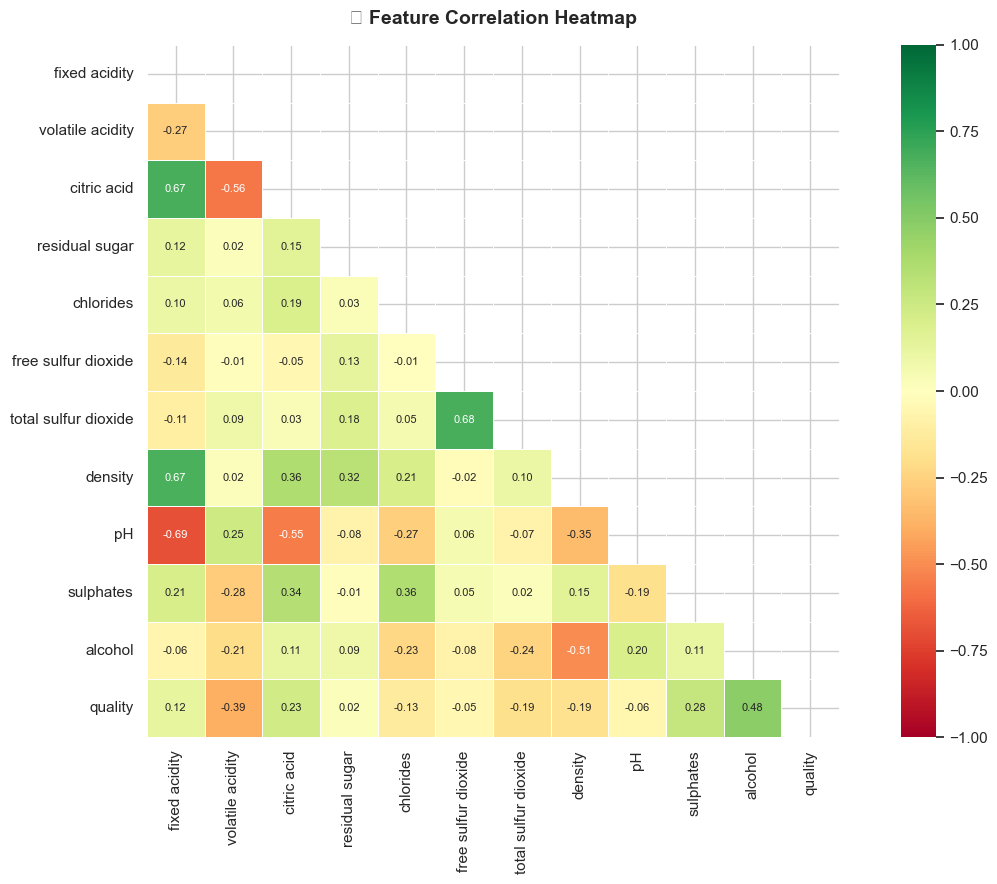


📊 Top features correlated with quality:
alcohol                 0.482849
volatile acidity        0.392550
sulphates               0.280678
citric acid             0.230840
total sulfur dioxide    0.194937
density                 0.185798
chlorides               0.132134
fixed acidity           0.120986
pH                      0.058713
free sulfur dioxide     0.050810
residual sugar          0.020484


In [20]:
# ── 4.2 Correlation Heatmap ───────────────────────────────────────────────────
plt.figure(figsize=(13, 9))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, square=True, vmin=-1, vmax=1,
            annot_kws={'size': 8})
plt.title('🔥 Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation.png', bbox_inches='tight')
plt.show()
print('\n📊 Top features correlated with quality:')
print(corr['quality'].drop('quality').abs().sort_values(ascending=False).to_string())

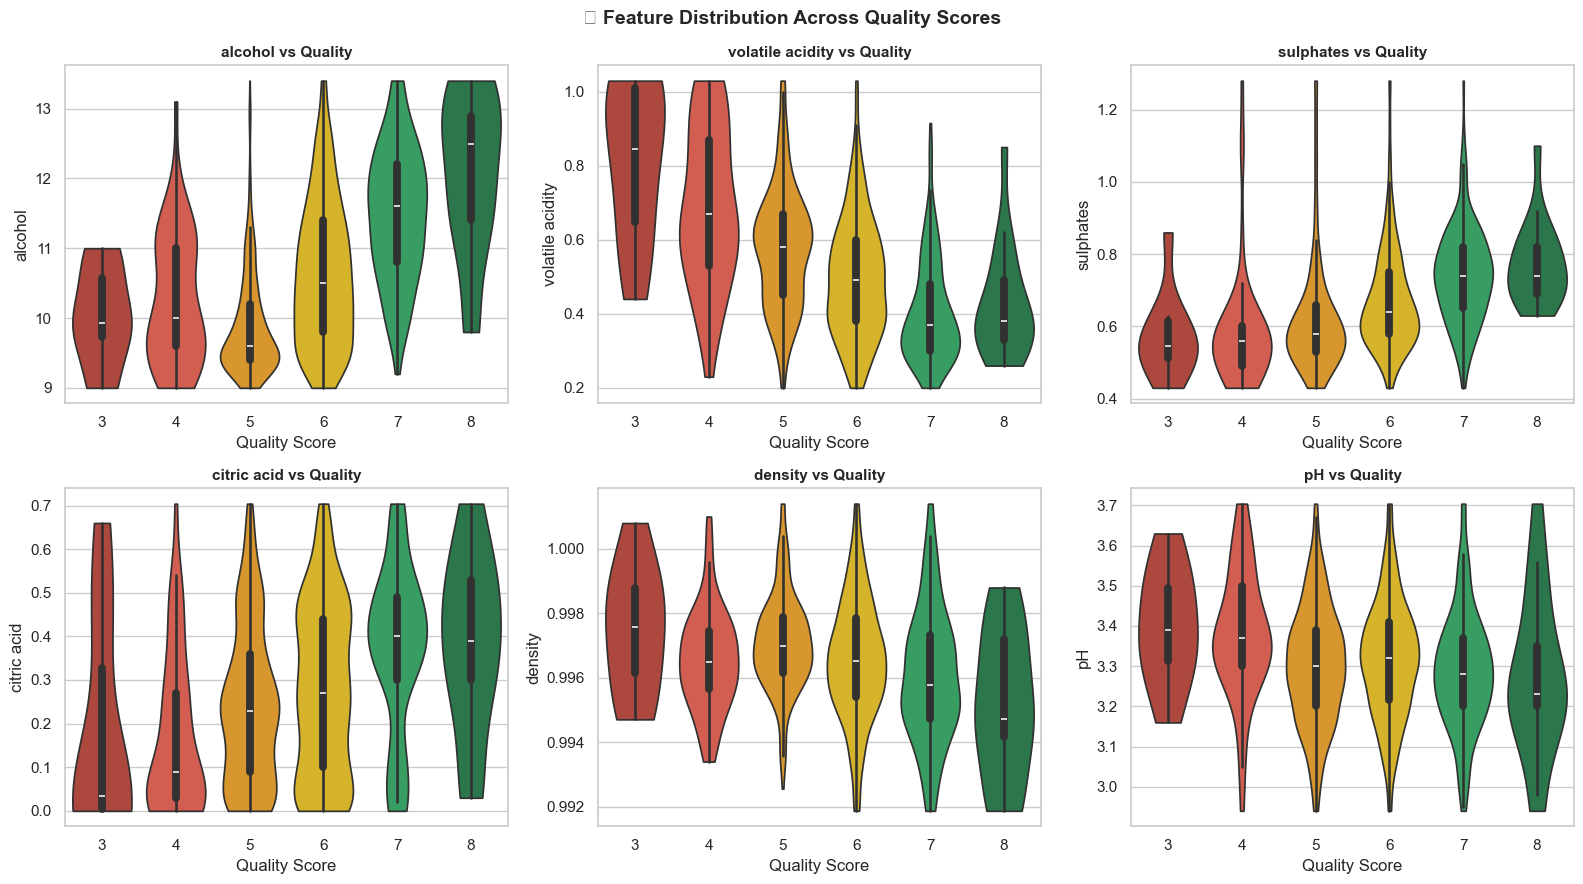

In [22]:
# ── 4.3 Feature vs Quality Violin Plots ───────────────────────────────────────
top_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'density', 'pH']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# ✅ FIX: use string keys to match seaborn's internal type conversion
palette = {'3':'#c0392b', '4':'#e74c3c', '5':'#f39c12', '6':'#f1c40f', '7':'#27ae60', '8':'#1e8449'}

for i, feat in enumerate(top_features):
    sns.violinplot(data=df_clean, x='quality', y=feat, ax=axes[i],
                   palette=palette, inner='box', cut=0)
    axes[i].set_title(f'{feat} vs Quality', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Quality Score')
    axes[i].set_ylabel(feat)

plt.suptitle('🎻 Feature Distribution Across Quality Scores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('violin.png', bbox_inches='tight')
plt.show()

In [23]:
# ── 5.1 Create Quality Labels ─────────────────────────────────────────────────
def label_quality(score):
    if score >= 7:   return 'Good'    # 🟢
    elif score >= 5: return 'Average' # 🟡
    else:            return 'Bad'     # 🔴

df_clean['quality_label'] = df_clean['quality'].apply(label_quality)

label_counts = df_clean['quality_label'].value_counts()
print('Quality Label Distribution:')
for label, count in label_counts.items():
    emoji = '🟢' if label == 'Good' else ('🟡' if label == 'Average' else '🔴')
    pct = 100 * count / len(df_clean)
    print(f'  {emoji} {label:8s} → {count:4d} samples ({pct:.1f}%)')

Quality Label Distribution:
  🟡 Average  → 1112 samples (81.8%)
  🟢 Good     →  184 samples (13.5%)
  🔴 Bad      →   63 samples (4.6%)


In [24]:
# ── 5.2 Label Encoding ────────────────────────────────────────────────────────
le = LabelEncoder()
le.fit(['Bad', 'Average', 'Good'])  # Explicit order: 0=Bad, 1=Average, 2=Good
df_clean['quality_encoded'] = le.transform(df_clean['quality_label'])

print('Label Encoding Map:')
for cls, code in zip(le.classes_, le.transform(le.classes_)):
    emoji = '🟢' if cls == 'Good' else ('🟡' if cls == 'Average' else '🔴')
    print(f'  {emoji} {cls} → {code}')

Label Encoding Map:
  🟡 Average → 0
  🔴 Bad → 1
  🟢 Good → 2


In [25]:
# ── 5.3 Feature Engineering ───────────────────────────────────────────────────
df_model = df_clean.copy()

# Interaction features
df_model['alcohol_sulphates']   = df_model['alcohol'] * df_model['sulphates']
df_model['acid_ratio']          = df_model['fixed acidity'] / (df_model['volatile acidity'] + 0.001)
df_model['sulfur_ratio']        = df_model['free sulfur dioxide'] / (df_model['total sulfur dioxide'] + 0.001)

print(f'✅ Feature engineering done → {df_model.shape[1]} total columns')
print('New features: alcohol_sulphates, acid_ratio, sulfur_ratio')

✅ Feature engineering done → 17 total columns
New features: alcohol_sulphates, acid_ratio, sulfur_ratio


In [26]:
# ── 5.4 Train-Test Split ──────────────────────────────────────────────────────
feature_cols = list(features) + ['alcohol_sulphates', 'acid_ratio', 'sulfur_ratio']

X = df_model[feature_cols]
y = df_model['quality_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Data Split:')
print(f'   Training set : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'   Test set     : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'   Features     : {X_train.shape[1]}')

✅ Data Split:
   Training set : 1087 samples (80%)
   Test set     : 272 samples (20%)
   Features     : 14


In [27]:
# ── 5.5 Feature Scaling ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ StandardScaler applied')
print(f'   Mean (first 3 features): {X_train_scaled.mean(axis=0)[:3].round(4)}')
print(f'   Std  (first 3 features): {X_train_scaled.std(axis=0)[:3].round(4)}')

✅ StandardScaler applied
   Mean (first 3 features): [ 0.  0. -0.]
   Std  (first 3 features): [1. 1. 1.]


In [28]:
# ── 6.1 Define Models ─────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=10,
                                                   random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=200, learning_rate=0.1,
                                          max_depth=6, random_state=42,
                                          eval_metric='mlogloss', verbosity=0),
    'SVM':                 SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
}

print('Models to train:')
for name in models:
    print(f'  • {name}')

Models to train:
  • Logistic Regression
  • Random Forest
  • XGBoost
  • SVM


In [29]:
# ── 6.2 Train & Evaluate All Models ──────────────────────────────────────────
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f'\n🔧 Training: {name}')

    # Train
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    cv_s = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')

    results[name] = {
        'model': model, 'y_pred': y_pred,
        'accuracy': acc, 'f1': f1,
        'cv_mean': cv_s.mean(), 'cv_std': cv_s.std()
    }

    print(f'   Accuracy     : {acc:.4f}')
    print(f'   F1-Score     : {f1:.4f}')
    print(f'   CV Accuracy  : {cv_s.mean():.4f} ± {cv_s.std():.4f}')


🔧 Training: Logistic Regression
   Accuracy     : 0.8419
   F1-Score     : 0.8059
   CV Accuracy  : 0.8326 ± 0.0084

🔧 Training: Random Forest
   Accuracy     : 0.8272
   F1-Score     : 0.7997
   CV Accuracy  : 0.8344 ± 0.0140

🔧 Training: XGBoost
   Accuracy     : 0.8272
   F1-Score     : 0.8024
   CV Accuracy  : 0.8335 ± 0.0201

🔧 Training: SVM
   Accuracy     : 0.8456
   F1-Score     : 0.8034
   CV Accuracy  : 0.8390 ± 0.0126


In [30]:
# ── 6.3 Model Comparison Table ────────────────────────────────────────────────
comparison_df = pd.DataFrame([
    {'Model': k, 'Test Accuracy': f"{v['accuracy']:.4f}",
     'F1-Score': f"{v['f1']:.4f}",
     'CV Mean': f"{v['cv_mean']:.4f}",
     'CV Std': f"±{v['cv_std']:.4f}"}
    for k, v in results.items()
])
print('\n📊 Model Comparison:')
print(comparison_df.to_string(index=False))


📊 Model Comparison:
              Model Test Accuracy F1-Score CV Mean  CV Std
Logistic Regression        0.8419   0.8059  0.8326 ±0.0084
      Random Forest        0.8272   0.7997  0.8344 ±0.0140
            XGBoost        0.8272   0.8024  0.8335 ±0.0201
                SVM        0.8456   0.8034  0.8390 ±0.0126


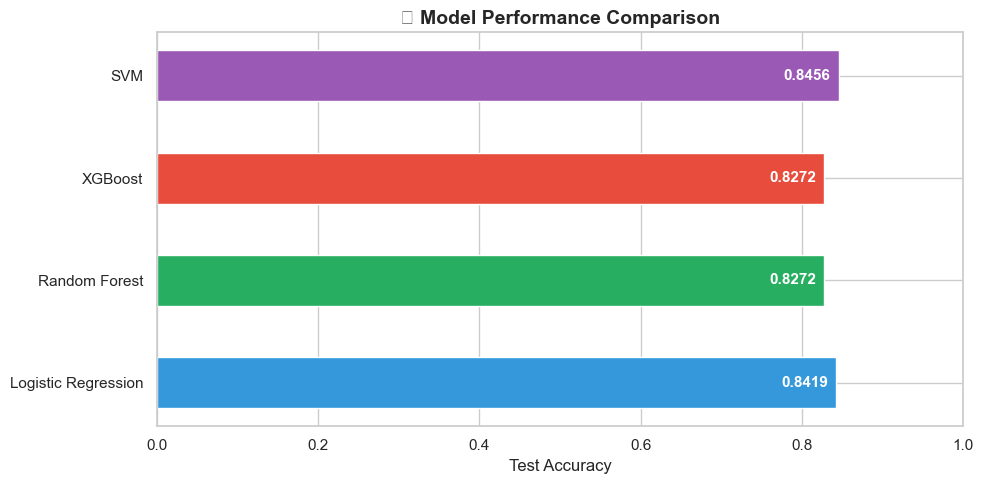

In [31]:
# ── 6.4 Model Accuracy Bar Chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
names = list(results.keys())
accs  = [results[n]['accuracy'] for n in names]
bars  = ax.barh(names, accs, color=['#3498db','#27ae60','#e74c3c','#9b59b6'],
                edgecolor='white', height=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() - 0.01, bar.get_y()+bar.get_height()/2,
            f'{acc:.4f}', va='center', ha='right', fontsize=11,
            fontweight='bold', color='white')
ax.set_xlim(0, 1)
ax.set_xlabel('Test Accuracy', fontsize=12)
ax.set_title('🤖 Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

In [32]:
# ── 7.1 Select Best Model ─────────────────────────────────────────────────────
best_name = max(results, key=lambda k: results[k]['accuracy'])
best      = results[best_name]
print(f'🏆 Best Model: {best_name}')
print(f'   Accuracy : {best["accuracy"]:.4f}')
print(f'   F1-Score : {best["f1"]:.4f}')

🏆 Best Model: SVM
   Accuracy : 0.8456
   F1-Score : 0.8034


In [33]:
# ── 7.2 Classification Report ─────────────────────────────────────────────────
print(f'\n📋 Classification Report — {best_name}')
print('=' * 60)
print(classification_report(
    y_test, best['y_pred'],
    target_names=['🔴 Bad', '🟡 Average', '🟢 Good']
))


📋 Classification Report — SVM
              precision    recall  f1-score   support

       🔴 Bad       0.85      0.99      0.91       222
   🟡 Average       0.00      0.00      0.00        13
      🟢 Good       0.79      0.30      0.43        37

    accuracy                           0.85       272
   macro avg       0.54      0.43      0.45       272
weighted avg       0.80      0.85      0.80       272



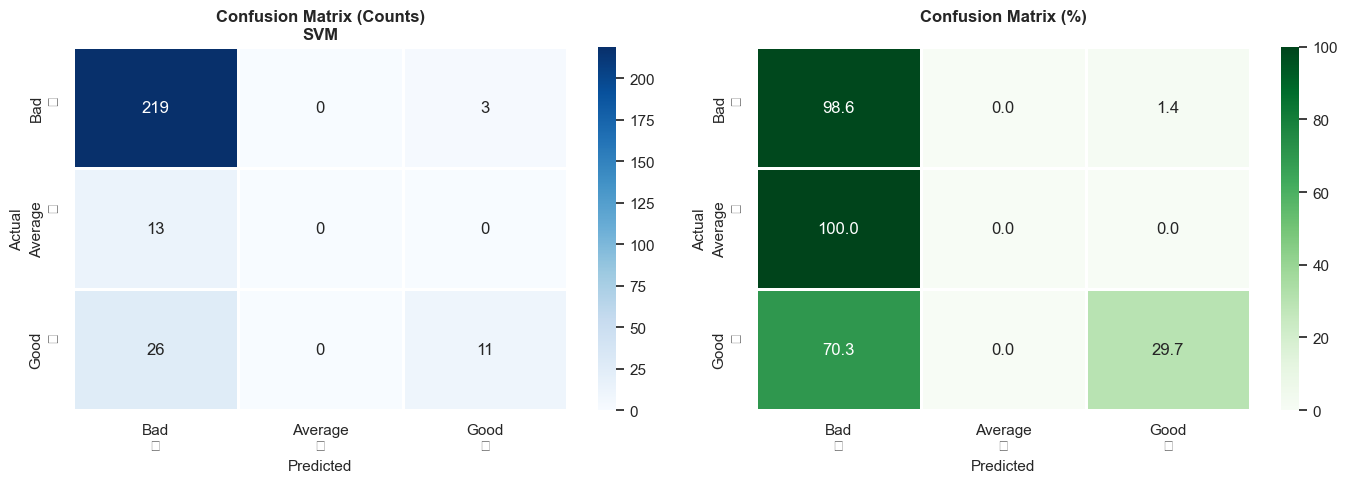

In [34]:
# ── 7.3 Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test, best['y_pred'])
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ['Bad\n🔴', 'Average\n🟡', 'Good\n🟢']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0],
            linewidths=1, linecolor='white')
axes[0].set_title(f'Confusion Matrix (Counts)\n{best_name}', fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual', fontsize=11)

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=labels, yticklabels=labels, ax=axes[1],
            linewidths=1, linecolor='white')
axes[1].set_title('Confusion Matrix (%)\n', fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Actual', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

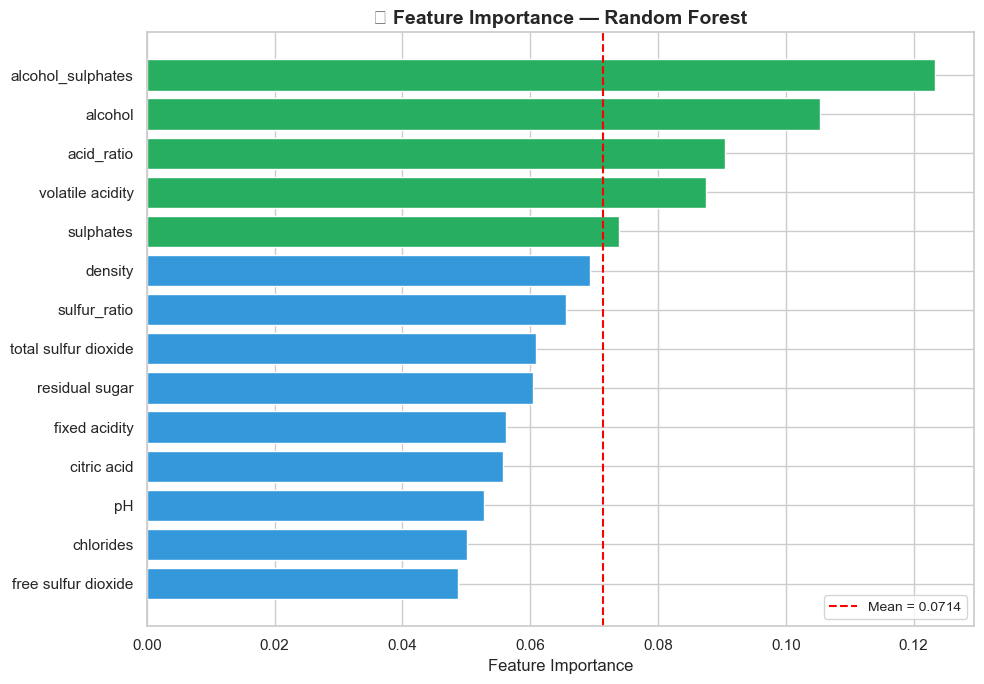

In [35]:
# ── 7.4 Feature Importance (Random Forest / XGBoost) ─────────────────────────
fi_model_name = 'Random Forest' if 'Random Forest' in results else best_name
fi_model = results[fi_model_name]['model']

if hasattr(fi_model, 'feature_importances_'):
    fi = pd.Series(fi_model.feature_importances_, index=feature_cols)
    fi = fi.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors_fi = ['#27ae60' if v > fi.mean() else '#3498db' for v in fi.values]
    bars = ax.barh(fi.index, fi.values, color=colors_fi, edgecolor='white')
    ax.axvline(fi.mean(), color='red', linestyle='--', label=f'Mean = {fi.mean():.4f}')
    ax.set_xlabel('Feature Importance', fontsize=12)
    ax.set_title(f'🌲 Feature Importance — {fi_model_name}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig('feature_importance.png', bbox_inches='tight')
    plt.show()
else:
    print(f'Feature importance not available for {fi_model_name}')

In [36]:
# ── 8.1 Save Best Model & Scaler ─────────────────────────────────────────────
os.makedirs('model', exist_ok=True)

joblib.dump(results[best_name]['model'], 'model/best_model.pkl')
joblib.dump(scaler,                     'model/scaler.pkl')
joblib.dump(le,                         'model/label_encoder.pkl')
joblib.dump(feature_cols,               'model/feature_cols.pkl')

print('✅ Saved to model/ directory:')
print('   • model/best_model.pkl')
print('   • model/scaler.pkl')
print('   • model/label_encoder.pkl')
print('   • model/feature_cols.pkl')
print(f'\n🏆 Best Model: {best_name} | Accuracy: {best["accuracy"]:.4f}')

✅ Saved to model/ directory:
   • model/best_model.pkl
   • model/scaler.pkl
   • model/label_encoder.pkl
   • model/feature_cols.pkl

🏆 Best Model: SVM | Accuracy: 0.8456


In [37]:
# ── 9.1 Prediction Function ───────────────────────────────────────────────────
def predict_wine_quality(sample_dict):
    """Predict quality for a new wine sample.
    sample_dict: dict with the 11 base feature values
    Returns: label (str) and probabilities (dict)
    """
    model    = joblib.load('model/best_model.pkl')
    sc       = joblib.load('model/scaler.pkl')
    enc      = joblib.load('model/label_encoder.pkl')
    f_cols   = joblib.load('model/feature_cols.pkl')

    row = pd.DataFrame([sample_dict])
    row['alcohol_sulphates'] = row['alcohol'] * row['sulphates']
    row['acid_ratio']        = row['fixed acidity'] / (row['volatile acidity'] + 0.001)
    row['sulfur_ratio']      = row['free sulfur dioxide'] / (row['total sulfur dioxide'] + 0.001)

    X_in = sc.transform(row[f_cols])
    pred = model.predict(X_in)[0]
    prob = model.predict_proba(X_in)[0]

    label = enc.inverse_transform([pred])[0]
    probs = {enc.inverse_transform([i])[0]: round(float(p)*100, 2) for i, p in enumerate(prob)}
    return label, probs


# ── 9.2 Test Prediction ───────────────────────────────────────────────────────
sample = {
    'fixed acidity': 8.5,    'volatile acidity': 0.28,
    'citric acid': 0.56,     'residual sugar': 1.8,
    'chlorides': 0.075,      'free sulfur dioxide': 17.0,
    'total sulfur dioxide': 60.0, 'density': 0.9980,
    'pH': 3.16,              'sulphates': 0.58,
    'alcohol': 9.8
}

label, probs = predict_wine_quality(sample)
emoji = '🟢' if label == 'Good' else ('🟡' if label == 'Average' else '🔴')
print(f'{emoji} Predicted Wine Quality: {label}')
print('\nClass Probabilities:')
for cls, p in sorted(probs.items(), key=lambda x: x[1], reverse=True):
    e = '🟢' if cls == 'Good' else ('🟡' if cls == 'Average' else '🔴')
    bar = '█' * int(p / 5)
    print(f'  {e} {cls:8s}: {p:5.1f}%  {bar}')

🟡 Predicted Wine Quality: Average

Class Probabilities:
  🟡 Average :  94.2%  ██████████████████
  🟢 Good    :   4.3%  
  🔴 Bad     :   1.5%  


In [38]:
# ── Final Summary Dashboard ───────────────────────────────────────────────────
print('='*60)
print('  🍷 WINE QUALITY ANALYSIS — FINAL SUMMARY')
print('='*60)
print(f'  Dataset     : {df_clean.shape[0]} samples × {df_clean.shape[1]} features')
print(f'  Train/Test  : {X_train.shape[0]} / {X_test.shape[0]}')
print(f'  Features    : {len(feature_cols)} (incl. 3 engineered)')
print()
print('  Model Leaderboard:')
print(f'  {"─"*45}')
for i, (n, v) in enumerate(sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True), 1):
    trophy = ['🥇','🥈','🥉','  '][min(i-1,3)]
    print(f'  {trophy} #{i} {n:22s} → Acc: {v["accuracy"]:.4f}  F1: {v["f1"]:.4f}')
print(f'  {"─"*45}')
print(f'\n  ✅ Best Model : {best_name}')
print(f'  ✅ Accuracy   : {best["accuracy"]:.4f} ({best["accuracy"]*100:.1f}%)')
print(f'  ✅ F1-Score   : {best["f1"]:.4f}')
print()
print('  Next step: Run Streamlit UI → streamlit run app.py')
print('='*60)

  🍷 WINE QUALITY ANALYSIS — FINAL SUMMARY
  Dataset     : 1359 samples × 14 features
  Train/Test  : 1087 / 272
  Features    : 14 (incl. 3 engineered)

  Model Leaderboard:
  ─────────────────────────────────────────────
  🥇 #1 SVM                    → Acc: 0.8456  F1: 0.8034
  🥈 #2 Logistic Regression    → Acc: 0.8419  F1: 0.8059
  🥉 #3 Random Forest          → Acc: 0.8272  F1: 0.7997
     #4 XGBoost                → Acc: 0.8272  F1: 0.8024
  ─────────────────────────────────────────────

  ✅ Best Model : SVM
  ✅ Accuracy   : 0.8456 (84.6%)
  ✅ F1-Score   : 0.8034

  Next step: Run Streamlit UI → streamlit run app.py
